# 01 — Data Ingestion

Builds `clickworthy.duckdb` from the raw Upworthy Research Archive CSV, verifies the schema against the facts documented in `CLAUDE.md`, quantifies what the standard filters remove, and takes a first exploratory look at the core distributions and at the `significance` / `first_place` / `winner` columns.

**View used:** `v_exploratory_clean` (built by `clickworthy.data_access`), except in the schema-verification and filter-accounting sections, which deliberately look at the raw table first.

No confirmatory-sample data appears anywhere in this notebook — per the archive's preregistration design (see CLAUDE.md's Data section), the confirmatory sample is reserved for a one-time validation check in Stage 4c, after Stages 1-3's claims are finalized, and is not touched during any earlier exploration or development.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from clickworthy import data_access as da

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100

con = da.build_database()
con

## 1. Schema verification

Check the raw table against the facts stated in `CLAUDE.md`: the 16 documented columns, one row per package, 22,666 packages across 4,873 tests, and no `problem` column (it was added in a June 2024 archive update; our March 2020 snapshot predates it).


In [2]:
EXPECTED_COLUMNS = [
    "created_at", "updated_at", "clickability_test_id", "excerpt", "headline",
    "lede", "slug", "eyecatcher_id", "impressions", "clicks", "significance",
    "first_place", "winner", "share_text", "square", "test_week",
]

raw_columns = con.execute(f"SELECT * FROM {da.RAW_TABLE} LIMIT 0").df().columns.tolist()
assert raw_columns == EXPECTED_COLUMNS, f"Schema mismatch: {raw_columns}"
assert "problem" not in raw_columns, "Unexpected 'problem' column — archive version may have changed."

n_packages, n_tests = con.execute(
    f"SELECT COUNT(*), COUNT(DISTINCT clickability_test_id) FROM {da.RAW_TABLE}"
).fetchone()
assert n_packages == 22_666, f"Expected 22,666 packages, got {n_packages}"
assert n_tests == 4_873, f"Expected 4,873 tests, got {n_tests}"

print(f"Columns match CLAUDE.md's documented schema ({len(raw_columns)} columns), 'problem' absent as expected.")
print(f"{n_packages:,} packages across {n_tests:,} tests — matches the archive's documented exploratory-sample size.")

Columns match CLAUDE.md's documented schema (16 columns), 'problem' absent as expected.
22,666 packages across 4,873 tests — matches the archive's documented exploratory-sample size.


## 2. Filter accounting

`v_exploratory_clean` applies the two standard filters from `CLAUDE.md`, cumulatively:

1. **Date-window exclusion** — drop packages/tests with `created_at` in `[2013-06-25, 2014-01-10]`. This stands in for the `problem` column absent from this file version; the archive's own docs define the affected date range identically to the `problem` flag.
2. **Degenerate-test exclusion** — drop tests with fewer than 2 packages, or any package with 0 impressions.

The table below counts packages, tests, and total impressions remaining after each step.


In [3]:
accounting = da.filter_accounting(con)
accounting["pct_packages_remaining"] = (
    100 * accounting["n_packages"] / accounting["n_packages"].iloc[0]
).round(1)
accounting

,step,n_packages,n_tests,total_impressions,pct_packages_remaining
0,0_raw,22666,4873,81024151.0,100.0
1,1_after_date_exclusion,18388,3823,64188299.0,81.1
2,2_after_degenerate_test_exclusion,18388,3823,64188299.0,81.1


**Interpretation:** the date-window exclusion (standing in for the missing `problem` column) does essentially all of the filtering work here — it removes a substantial fraction of tests concentrated in the mid-2013–early-2014 randomization-defect window. The degenerate-test filter removes nothing further on top of that, i.e. among tests surviving the date cut, none have fewer than 2 packages or a zero-impression package. That's a useful sanity check: the archive's "clean" tests (post date-filter) are structurally well-formed, so we don't need to worry about single-arm or zero-traffic tests contaminating later stages.


### 2a. Independent verification of the degenerate-test claim

`filter_accounting()` reports that step 2 (degenerate-test exclusion) removes nothing on top of step 1. That claim is only as good as the SQL inside `_create_clean_view` and `filter_accounting` — both could share the same bug. Re-derive both conditions independently, directly against `v_exploratory_clean`, plus one check the filters don't cover at all: `clicks > impressions`, a data-integrity case Stage 1's CTR and Wilson-interval work will be sensitive to.


In [4]:
n_tests_lt_2_packages = con.execute(f"""
    SELECT COUNT(*) FROM (
        SELECT clickability_test_id
        FROM {da.CLEAN_VIEW}
        GROUP BY clickability_test_id
        HAVING COUNT(*) < 2
    )
""").fetchone()[0]

n_zero_or_null_impressions = con.execute(f"""
    SELECT COUNT(*) FROM {da.CLEAN_VIEW}
    WHERE impressions = 0 OR impressions IS NULL
""").fetchone()[0]

n_clicks_exceed_impressions = con.execute(f"""
    SELECT COUNT(*) FROM {da.CLEAN_VIEW}
    WHERE clicks > impressions
""").fetchone()[0]

print(f"Tests with fewer than 2 packages in v_exploratory_clean: {n_tests_lt_2_packages}")
print(f"Packages with 0 or null impressions in v_exploratory_clean: {n_zero_or_null_impressions}")
print(f"Packages with clicks > impressions in v_exploratory_clean: {n_clicks_exceed_impressions}")

assert n_tests_lt_2_packages == 0, "BUG: single-arm test(s) survived the degenerate-test filter."
assert n_zero_or_null_impressions == 0, "BUG: zero/null-impression package(s) survived the degenerate-test filter."
assert n_clicks_exceed_impressions == 0, "DATA INTEGRITY ISSUE: clicks > impressions found — investigate before Stage 1."

Tests with fewer than 2 packages in v_exploratory_clean: 0
Packages with 0 or null impressions in v_exploratory_clean: 0
Packages with clicks > impressions in v_exploratory_clean: 0


**Result: all three counts are 0.** No test in `v_exploratory_clean` has fewer than 2 surviving packages, no package has 0 or null impressions, and no package has more clicks than impressions anywhere in the view. This is the actual confirmation of Stage 0's degenerate-test claim — independent of `filter_accounting()`'s own reporting — and it also clears the `clicks > impressions` data-integrity case that neither standard filter checks. Proceeding to Stage 1 on this basis.


## 3. Exploratory plots on the core distributions

All plots below use `v_exploratory_clean` — the filtered view that later stages build on. Look at the data before any modeling: how many arms tests typically have, how much traffic arms typically get, and what the raw click-through rates look like.


In [5]:
clean = con.execute(f"SELECT * FROM {da.CLEAN_VIEW}").df()
clean["ctr"] = clean["clicks"] / clean["impressions"]
clean.shape

(18388, 17)

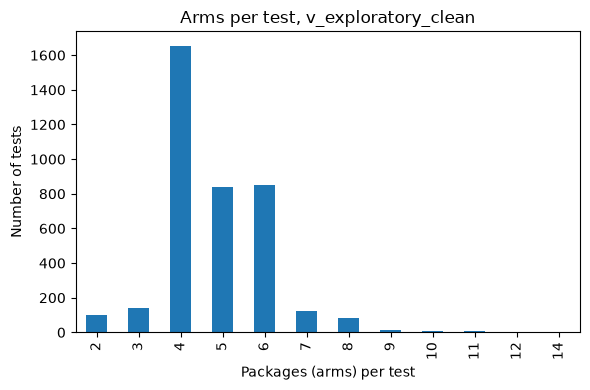

count    3823.000000
mean        4.809835
std         1.240005
min         2.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


In [6]:
packages_per_test = clean.groupby("clickability_test_id").size()

fig, ax = plt.subplots(figsize=(6, 4))
packages_per_test.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Packages (arms) per test")
ax.set_ylabel("Number of tests")
ax.set_title("Arms per test, v_exploratory_clean")
plt.tight_layout()
plt.show()

print(packages_per_test.describe())

**Interpretation:** most tests have 4–6 arms (median 5, IQR 4–6), with a long right tail out to 14. Two-arm tests exist but are a small minority (~99 of 3,823). This matters for Stage 1: a chi-square across all arms is the right first cut for most tests, but pairwise comparisons need to account for the number of arms (more arms → more pairwise comparisons → BH correction matters more).


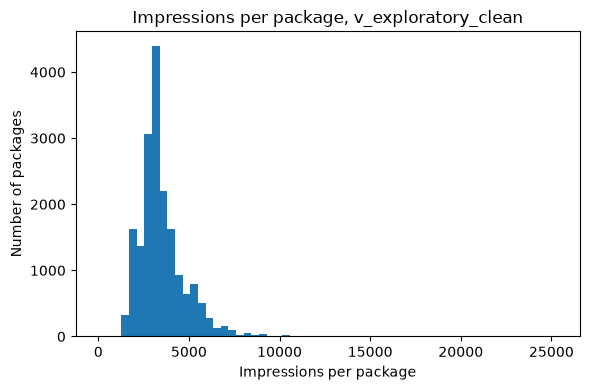

count    18388.000000
mean      3490.771101
std       1273.831005
min         13.000000
25%       2768.000000
50%       3118.000000
75%       4031.250000
max      25314.000000
Name: impressions, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(clean["impressions"], bins=60)
ax.set_xlabel("Impressions per package")
ax.set_ylabel("Number of packages")
ax.set_title("Impressions per package, v_exploratory_clean")
plt.tight_layout()
plt.show()

print(clean["impressions"].describe())

**Interpretation:** impressions per arm are right-skewed but not extreme (median ~3,118, mean ~3,491, max ~25,300) — most arms got a few thousand viewers. Combined with baseline CTRs around 1% (below), this puts many arms in a regime where per-arm click counts are only in the tens, which is exactly where normal-approximation CIs break down and Wilson intervals (per CLAUDE.md's convention) matter.


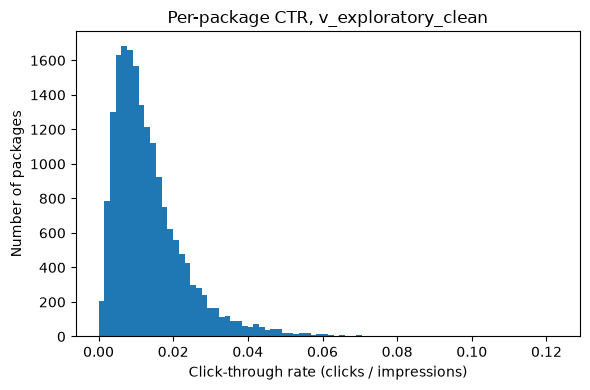

count    18388.000000
mean         0.013620
std          0.009928
min          0.000000
25%          0.006724
50%          0.011131
75%          0.017527
max          0.122842
Name: ctr, dtype: float64
Packages with CTR == 0: 10 (0.05%)


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(clean["ctr"], bins=80)
ax.set_xlabel("Click-through rate (clicks / impressions)")
ax.set_ylabel("Number of packages")
ax.set_title("Per-package CTR, v_exploratory_clean")
plt.tight_layout()
plt.show()

print(clean["ctr"].describe())
print(f"Packages with CTR == 0: {(clean['ctr'] == 0).sum()} ({(clean['ctr'] == 0).mean():.2%})")

**Interpretation:** CTR is heavily right-skewed with a median of ~1.1% and mean ~1.4% — consistent with CLAUDE.md's note that baseline CTRs are "order 1%". A small number of packages (~10) have exactly 0 clicks despite nonzero impressions, which is expected at this rate and this sample size, not a data-quality flag by itself. The low, skewed CTR is the core reason proportions here need careful treatment (Wilson/Newcombe CIs, binomial likelihoods on raw counts rather than pre-averaged CTRs) rather than normal approximations.


## 4. `significance` / `first_place` / `winner` — descriptive pass only

**This section is purely descriptive, not inferential.** Per `CLAUDE.md`: the exact method Upworthy used to compute `significance` was never recovered from former staff, and `significance`/`first_place` were shown to editors only to guide which package to select as `winner`. **We do not use these as a proxy for statistical significance anywhere in this project** — Stage 1 computes significance ourselves from `impressions`/`clicks`. The goal here is just to document what these columns look like: value ranges, missingness, and a rough (non-causal) relationship to observed CTR, so we know what we're choosing not to rely on.


In [9]:
print("significance — dtype:", clean["significance"].dtype)
print(clean["significance"].describe())
print("missing:", clean["significance"].isna().sum())
print()
print("first_place value counts:")
print(clean["first_place"].value_counts(dropna=False))
print()
print("winner value counts:")
print(clean["winner"].value_counts(dropna=False))

significance — dtype: float64
count    18388.000000
mean        40.281531
std         39.441435
min          0.000000
25%          2.800000
50%         25.200000
75%         83.200000
max        100.000000
Name: significance, dtype: float64
missing: 0

first_place value counts:
first_place
False    14594
True      3794
Name: count, dtype: int64

winner value counts:
winner
False    17491
True       897
Name: count, dtype: int64


**Observation:** `significance` is complete (no missing values) and ranges 0–100 with a roughly uniform-ish spread (median ~25, mean ~40) — it does not look like a p-value or a z-score on any standard scale, consistent with CLAUDE.md's note that its exact derivation is unrecovered. `first_place` is True for ~21% of packages (3,794 / 18,388) and `winner` for ~5% (897 / 18,388), which makes sense: `first_place` presumably marks the best-performing arm within its own test (so roughly one per test, and tests can tie or have ambiguous "first"), while `winner` is the editors' final pick, a much rarer designation.


In [10]:
# Rough (non-causal, purely descriptive) relationship to observed CTR.
print("Mean CTR by first_place:")
print(clean.groupby("first_place")["ctr"].mean())
print()
print("Mean CTR by winner:")
print(clean.groupby("winner")["ctr"].mean())
print()
print(f"Pearson corr(significance, ctr) = {clean['significance'].corr(clean['ctr']):.3f}")
print()
print("significance distribution by winner:")
print(clean.groupby("winner")["significance"].describe())


Mean CTR by first_place:
first_place
False    0.012552
True     0.017729
Name: ctr, dtype: float64

Mean CTR by winner:
winner
False    0.013293
True     0.019996
Name: ctr, dtype: float64

Pearson corr(significance, ctr) = 0.244

significance distribution by winner:
          count       mean        std  min   25%    50%    75%    max
winner                                                               
False   17491.0  37.759791  38.438794  0.0   2.4   22.0   73.8  100.0
True      897.0  89.454069  23.169621  0.0  96.0  100.0  100.0  100.0


In [11]:
con.close()

**Interpretation:** all three columns correlate with observed CTR in the expected direction — `first_place` packages average ~1.77% CTR vs ~1.26% for others, `winner` packages average ~2.00% vs ~1.33%, and `significance` correlates with CTR at r≈0.24. Winning packages skew heavily toward high `significance` (median 100, 25th percentile 96) versus non-winners (median 22). None of this validates `significance` as a real p-value or test statistic — it's exactly the pattern you'd expect if editors used *some* internal ranking that's correlated with, but not equivalent to, statistical significance as we'll define it in Stage 1. It also reinforces the winner's-curse concern flagged in CLAUDE.md: `winner`-selected packages are, by construction, a CTR-selected subsample, so their observed CTR is an upward-biased estimate of their true rate.


## Summary

- Schema and row/test counts match the archive's documented facts exactly.
- `v_exploratory_clean` retains 3,823 of 4,873 tests (18,388 of 22,666 packages) after the date-window exclusion; the degenerate-test filter removes nothing further.
- Tests typically have 4–6 arms; arms typically get a few thousand impressions; CTRs are low (~1%) and right-skewed — together these motivate the Wilson/Newcombe CIs and binomial-on-counts modeling conventions used from Stage 1 onward.
- `significance`/`first_place`/`winner` are documented as descriptive only; they correlate with observed CTR as expected but are not used as inferential significance anywhere downstream.

Next: `02_classical_ab.ipynb` (Stage 1).
